<a href="https://colab.research.google.com/github/gitnicolas343/intro_neurociencias_Computacionesles_phyton/blob/main/Lab7_Ruido_Neuronal_VClase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7 - Ruido

## Ejercicio 1.

Considere una neurona LIF sujeta a ruido blanco con valores de intensidad $\sigma = [1, 2, 3]$. Para cada valor simule la neurona hasta que genere por lo menos 1000 spikes.

1. Muestre en cada caso el gráfico del potencial de membrana en el tiempo en una ventana de tiempo corta
2. Calcule la distribución del ISI
3. Calcule la ACF del tren de spikes emitido
4. Calcule el espectro de potencia del tren de spikes.

Use el método de Euler Maruyama con $dt = 0.1$, use para el ejercicio los siguientes parámetros.

- $R = 1$, $I_{det} = 10$, $V_{rest}=V_{reset}=-65mV$, $V_{th} = -50mV$, $\tau_m = 10$



In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks,periodogram
import numpy as np

In [ ]:
# TODO
np.random.seed(10)                                               #reproducibilidad

#parametros
R = 1
I_det  = 10
V_rest = -65
V_th = -50
tau_m = 10
sigma = [1,2,3]


#corriente
def corriente_variable(iap ,corriente = 100):
    return corriente

#esta funcion implementa el LIF con ruido blanco gaussiano
def modeloscc(
              tiempo_inicial=0,
              tiempo_final=200000,
              paso_h=0.1,
              vol_restet = -65,
              cord_inicial = -65,
              corriente = 100,
              v_th1 = -55,
              funcion_corriente = corriente_variable,
              sigma_1= 1
              ):


    pico_spike = list()
    t = [float(tiempo_inicial)]
    tf = tiempo_final                                          #tiempo final
    h = paso_h                                                 #pasos de tiempo
    n = int(tf/h)                                              #numero de tiempo


    V = [float(cord_inicial)]                               #condicion inicial

    for i in range(n):                                      #ciclo principal del metodo de euler
        Vold = V[-1]                                        #variables en t0
        told = t[-1]
        I = funcion_corriente(told, corriente)              #aplicacion de la corriente en el tiempo old

        Vnew  = Vold + h*1/(tau_m)*(-(Vold - V_rest) + R*I)  +  np.sqrt(paso_h)*sigma_1*np.random.normal(0, 1)                 #metodo de euler con ruido gaussiano



        if Vnew <= v_th1:                                    #condicion de reinicio de V
            V.append(Vnew)                                   #si vnew es menor que v_th se agrega el new
            tnew =  told + h
            t.append(tnew)
        else:                                               #si no se agrega el reset

        #vi que el V no lleganba hasta el umbral sino que se quedaba hasta  el valor que tenia un paso antes que podia ser muy inferior al umbral
        #lo reformule para que V = Vth en el punto donde sucede y se reinicie un paso luego
            V.append(v_th1)
            pico_spike.append(told)
            t.append(told)
            tnew = told + h


            V.append(vol_restet)              # Reset

            t.append(tnew)






    return t,V,pico_spike                                     #variables de interes (retorno)


In [ ]:
#para sigma1

tiempo_f = 221000       #pasos que supongo inicialmente
picospike = list()     #inicio estas lista como vacias para irlas rederfiniendo dependiendo de las necesidade del ciclo while hasta
tiempo = list()        #que llegue a minimo 100 spikes
voltaje = list()
while len(picospike)<= 1000:              #ciclo que itera hasta que los picospike que es la lista que registra los spikes sea mayor o igual a 1090
    tiempo,voltaje,picospike = modeloscc(tiempo_final= tiempo_f,vol_restet =-65,v_th1 = -50, corriente= 10)  #la funcion se aplica
    tiempo_f += 10000                      #se actualiza los tiempos



In [ ]:
#para sigma 2

tiempo_f2 = 44000
picospike2 = list()
tiempo2 = list()
voltaje2 = list()
while len(picospike2)<= 1000:
    tiempo2,voltaje2,picospike2 = modeloscc(tiempo_final= tiempo_f2,vol_restet =-65,v_th1 = -50, corriente= 10, sigma_1 = 2 )
    tiempo_f2 += 500
    print(len(picospike2))

996
1021


In [ ]:
tiempo_f3 = 30000
picospike3 = list()
tiempo3 = list()
voltaje3 = list()
while len(picospike3)<= 1000:
    tiempo3,voltaje3,picospike3 = modeloscc(tiempo_final= tiempo_f3,vol_restet =-65,v_th1 = -50, corriente= 10, sigma_1 = 2 )
    tiempo_f3 += 1000
    print(len(picospike3))

727
698
744
738
745
837
782
859
836
882
908
910
946
980
1024


In [ ]:
#cantidad de spikes
print(f'cantidad de spikes para sigma_1: {len(picospike)}')
print(f'cantidad de spikes para sigma_2: {len(picospike2)}')
print(f'cantidad de spikes para sigma_3: {len(picospike3)}')

cantidad de spikes para sigma_1: 1117
cantidad de spikes para sigma_2: 1021
cantidad de spikes para sigma_3: 1024


In [ ]:
#para graficar spikes

#sigma_1
V_spikes = np.full_like(picospike, fill_value=-50)  #diferencias entre los tiempo que nos da la distribucion de isi
t_spike = np.array(picospike)
#sigma_2
V_spikes2 = np.full_like(picospike2, fill_value=-50)
t_spike2 = np.array(picospike2)
#sigma_3
V_spikes3 = np.full_like(picospike3, fill_value=-50)
t_spike3 = np.array(picospike3)

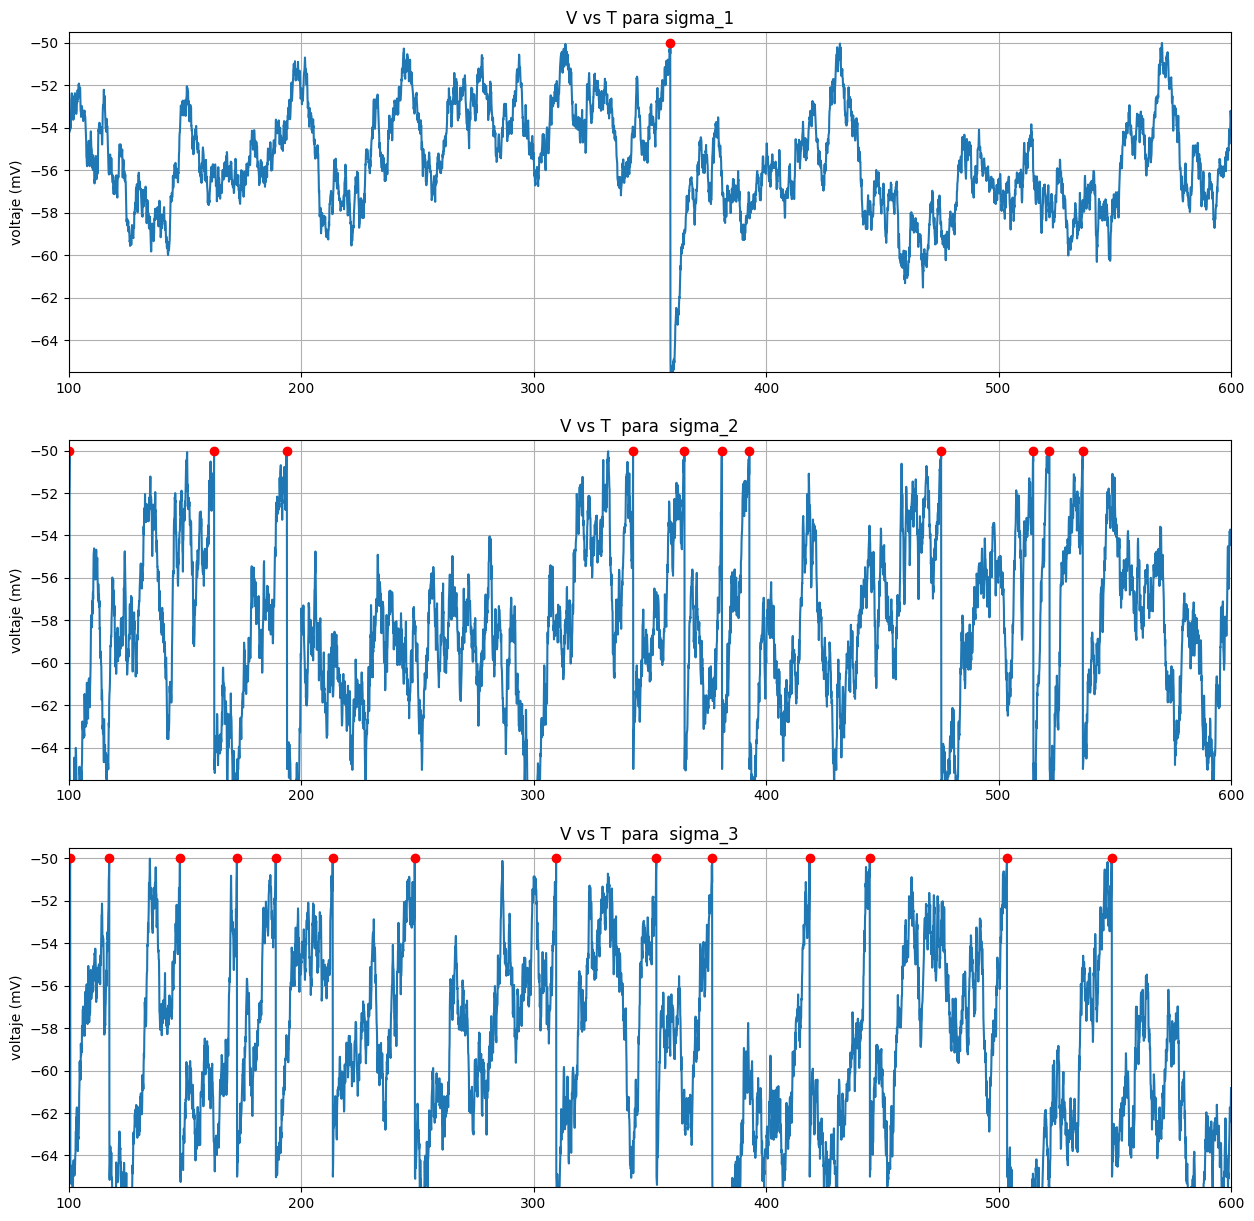

In [ ]:
#grafica de los potenciales de membrana

plt.figure(figsize=(15,15))

plt.subplot(3,1,1)
plt.title('V vs T para sigma_1')
plt.plot(tiempo,voltaje)
plt.plot(t_spike,V_spikes, 'ro')
plt.xlim(100,600)
plt.ylim(-65.5,-49.5)

plt.ylabel('voltaje (mV)')
plt.grid()

plt.subplot(3,1,2)
plt.title('V vs T  para  sigma_2')
plt.plot(tiempo2,voltaje2)
plt.plot(t_spike2,V_spikes2, 'ro')
plt.xlim(100,600)
plt.ylim(-65.5,-49.5)

plt.ylabel('voltaje (mV)')
plt.grid()

plt.subplot(3,1,3)
plt.title('V vs T  para  sigma_3')
plt.plot(tiempo3,voltaje3)
plt.plot(t_spike3,V_spikes3, 'ro')
plt.xlim(100,600)
plt.ylim(-65.5,-49.5)

plt.ylabel('voltaje (mV)')
plt.grid()



plt.show()

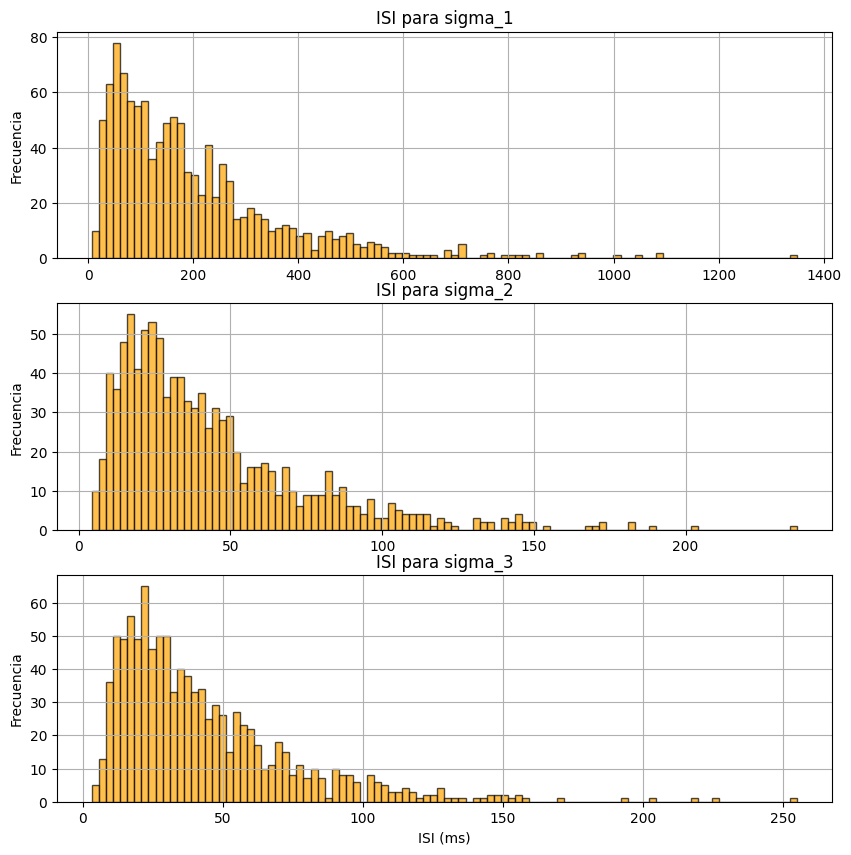

In [ ]:
#isi
isi = np.diff(picospike)
isi2 = np.diff(picospike2)
isi3 = np.diff(picospike3)


plt.figure(figsize = (10,10))
plt.subplot(3,1,1)
plt.title('ISI para sigma_1')
plt.hist(isi, bins=100, color='orange', alpha=0.7,edgecolor='black')

plt.ylabel('Frecuencia')
plt.grid()


plt.subplot(3,1,2)
plt.title('ISI para sigma_2')
plt.hist(isi2, bins=100, color='orange', alpha=0.7,edgecolor='black')

plt.ylabel('Frecuencia')
plt.grid()

plt.subplot(3,1,3)
plt.title('ISI para sigma_3')
plt.hist(isi3, bins=100, color='orange', alpha=0.7,edgecolor='black')
plt.xlabel('ISI (ms)')
plt.ylabel('Frecuencia')
plt.grid()


plt.show()


In [ ]:
#esta funcion calcula el tren de spikes 0,1 (cuando hay y cuando no hay) para una listan de tiempos de spike

def peaks_01_LIF(tiempo_spikes, tf, dt_bin=0.1):

    bins = np.arange(0, tf, dt_bin)
    spikes_binarios = list()

    for bin_inicio in bins:
        spike_en_bin = 0
        for spike in tiempo_spikes:
            if bin_inicio <= spike < (bin_inicio + dt_bin):
                spike_en_bin = 1
                break
        spikes_binarios.append(spike_en_bin)

    return spikes_binarios

In [ ]:
#aqui se aplica la funcion sobre los tiempos de los picos de spikes
spikes_binario_1 = peaks_01_LIF(picospike, tiempo_f,   1) #reduje el bin para que no tuebira tantos datos para procesarce en los calculos de correlate y potencia
spikes_binario_2 = peaks_01_LIF(picospike2, tiempo_f2, 1)
spikes_binario_3 = peaks_01_LIF(picospike3, tiempo_f3, 1)

In [ ]:
#bins dependiendop del tiempo  final de cada simulacion pues no es el mismo

bins_uso = np.arange(0,tiempo_f,1)
bins_uso2 = np.arange(0,tiempo_f2,1)
bins_uso3 = np.arange(0,tiempo_f3,1)


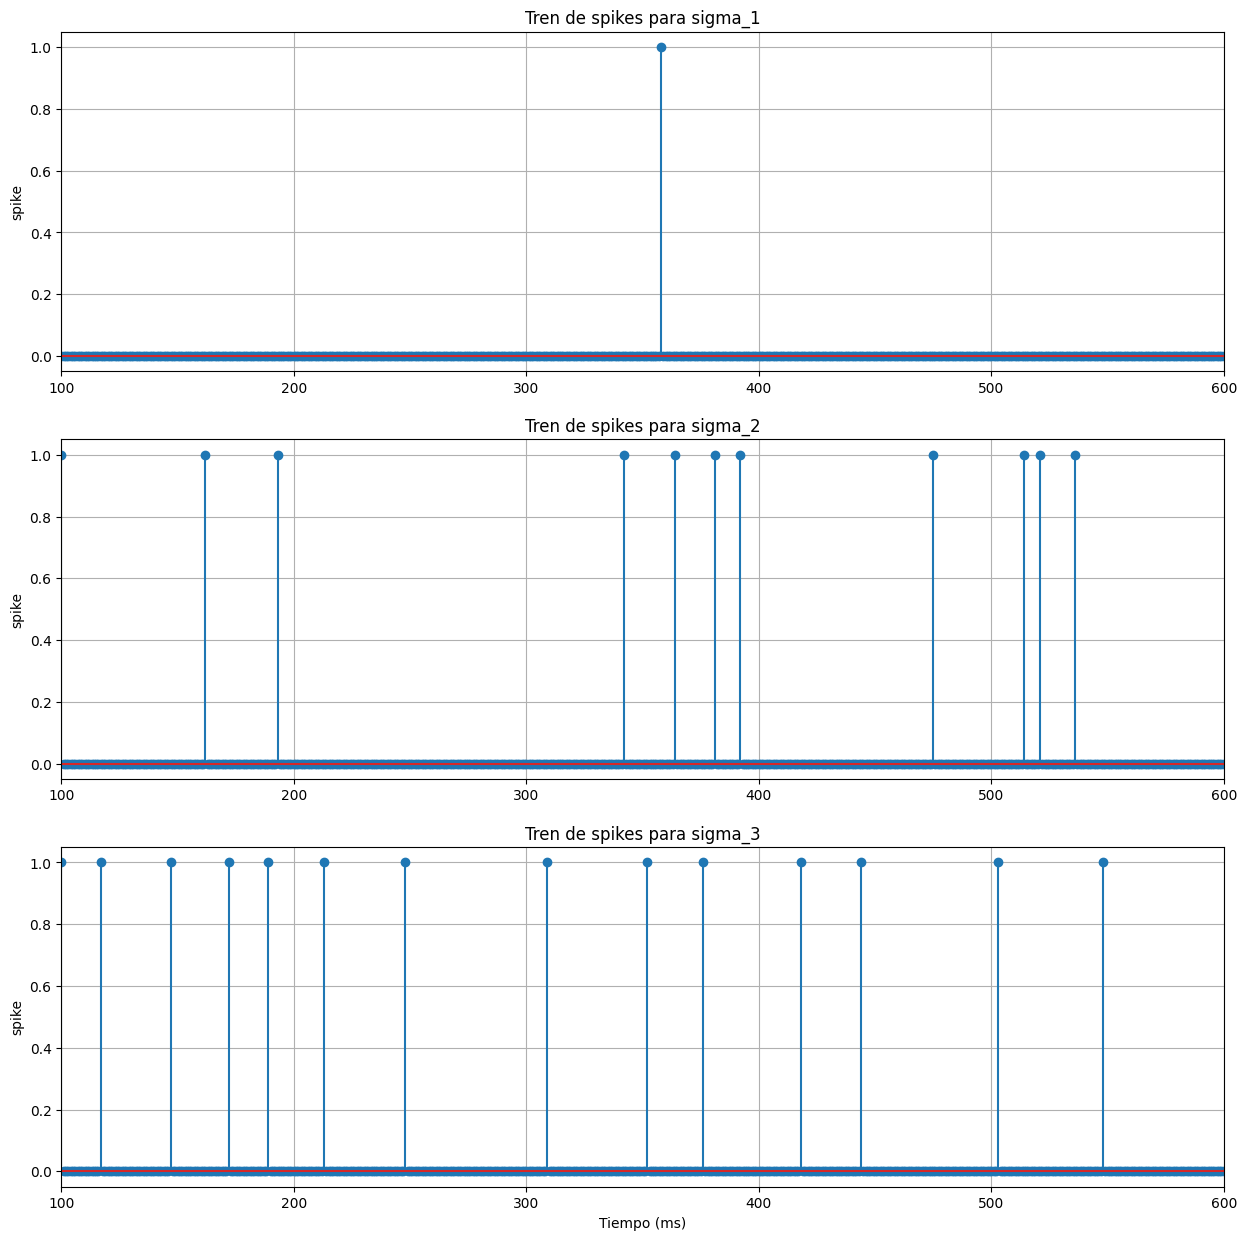

In [ ]:
#grafica tren de spikes

plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
plt.title('Tren de spikes para sigma_1')
plt.stem(bins_uso,spikes_binario_1)
plt.ylabel('spike')
plt.xlim(100,600)
plt.grid()

plt.subplot(3,1,2)
plt.title('Tren de spikes para sigma_2')
plt.stem(bins_uso2,spikes_binario_2)
plt.ylabel('spike')
plt.xlim(100,600)
plt.grid()

plt.subplot(3,1,3)
plt.title('Tren de spikes para sigma_3')
plt.stem(bins_uso3,spikes_binario_3)
plt.ylabel('spike')
plt.xlim(100,600)
plt.xlabel('Tiempo (ms)')
plt.grid()

plt.show()

In [ ]:
#funcion de autocorrelacion

correlacion_sigma_1 = np.correlate(np.array(spikes_binario_1) - np.mean(np.array(spikes_binario_1)),
                                   np.array(spikes_binario_1) - np.mean(np.array(spikes_binario_1)),
                                   mode='full') / len(spikes_binario_1)

correlacion_sigma_2 = np.correlate(np.array(spikes_binario_2) - np.mean(np.array(spikes_binario_2)),
                                   np.array(spikes_binario_2) - np.mean(np.array(spikes_binario_2)),
                                   mode='full') / len(spikes_binario_2)

correlacion_sigma_3 = np.correlate(np.array(spikes_binario_3) - np.mean(np.array(spikes_binario_3)),
                                   np.array(spikes_binario_3) - np.mean(np.array(spikes_binario_3)),
                                   mode='full') / len(spikes_binario_3)


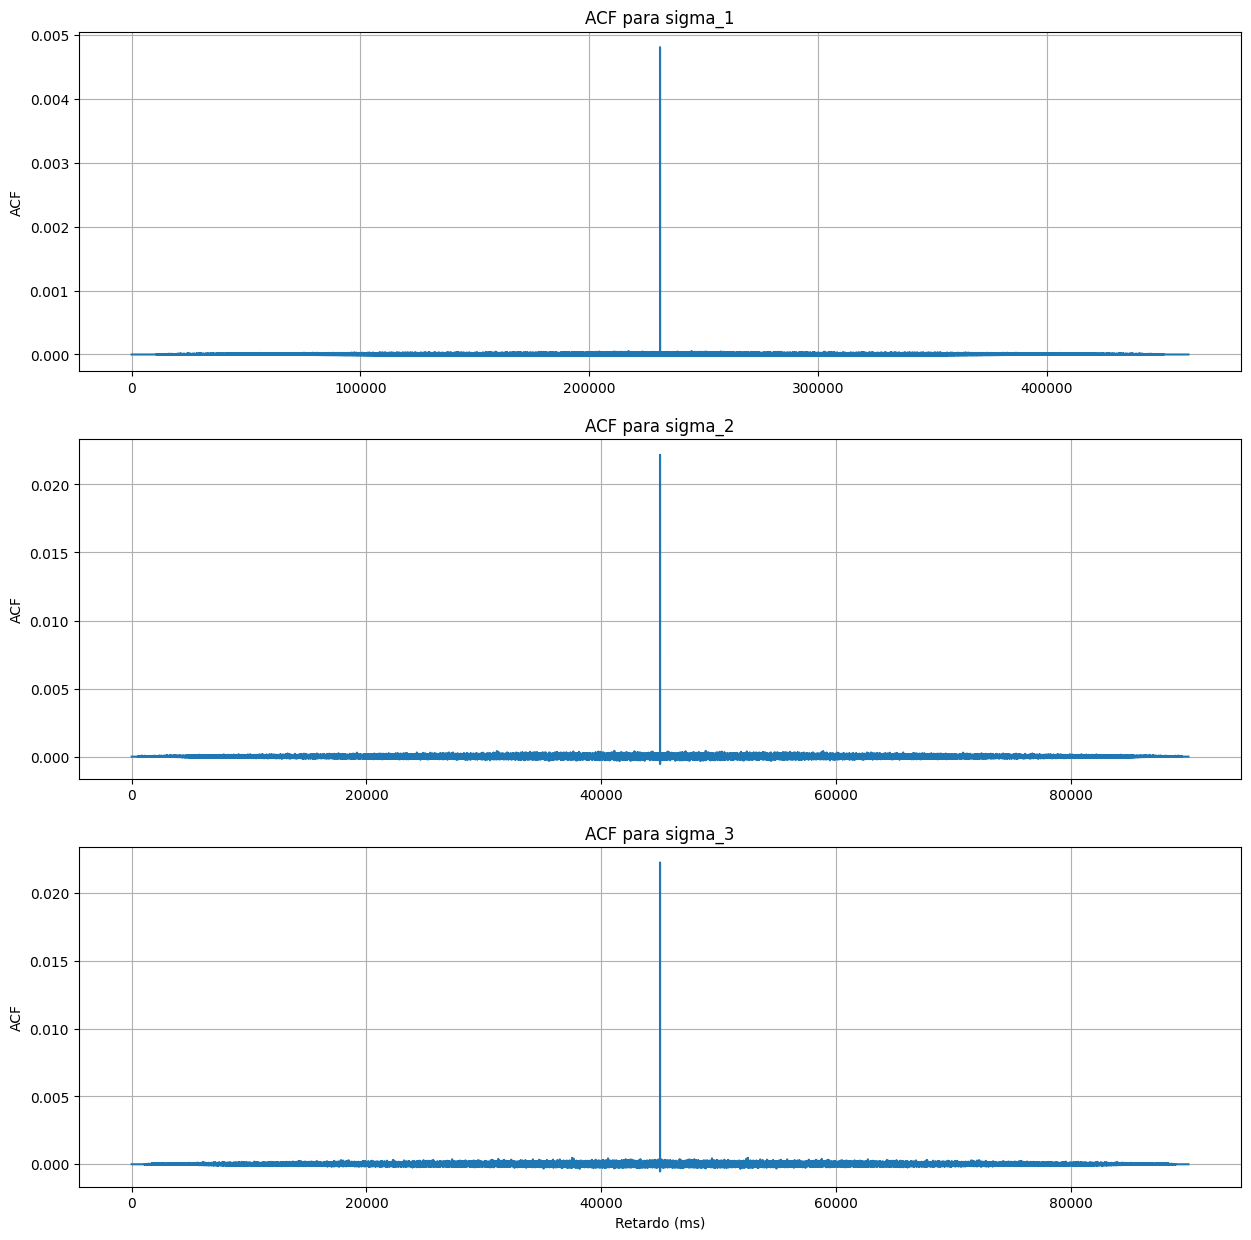

In [ ]:
#grafica de la ACF

plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
plt.title('ACF para sigma_1')
plt.plot(correlacion_sigma_1)
plt.ylabel('ACF')
plt.grid()

plt.subplot(3,1,2)
plt.title('ACF para sigma_2')
plt.plot(correlacion_sigma_2)
plt.ylabel('ACF')
plt.grid()

plt.subplot(3,1,3)
plt.title('ACF para sigma_3')
plt.plot(correlacion_sigma_3)
plt.ylabel('ACF')
plt.xlabel('Retardo (ms)')
plt.grid()

plt.show()


In [ ]:
#espectro de potencia usando peridogram

f_1 , Pxx_1= periodogram(spikes_binario_1, fs = 1/0.1)
f_2 , Pxx_2= periodogram(spikes_binario_2, fs = 1/0.1)
f_3 , Pxx_3= periodogram(spikes_binario_3, fs = 1/0.1)

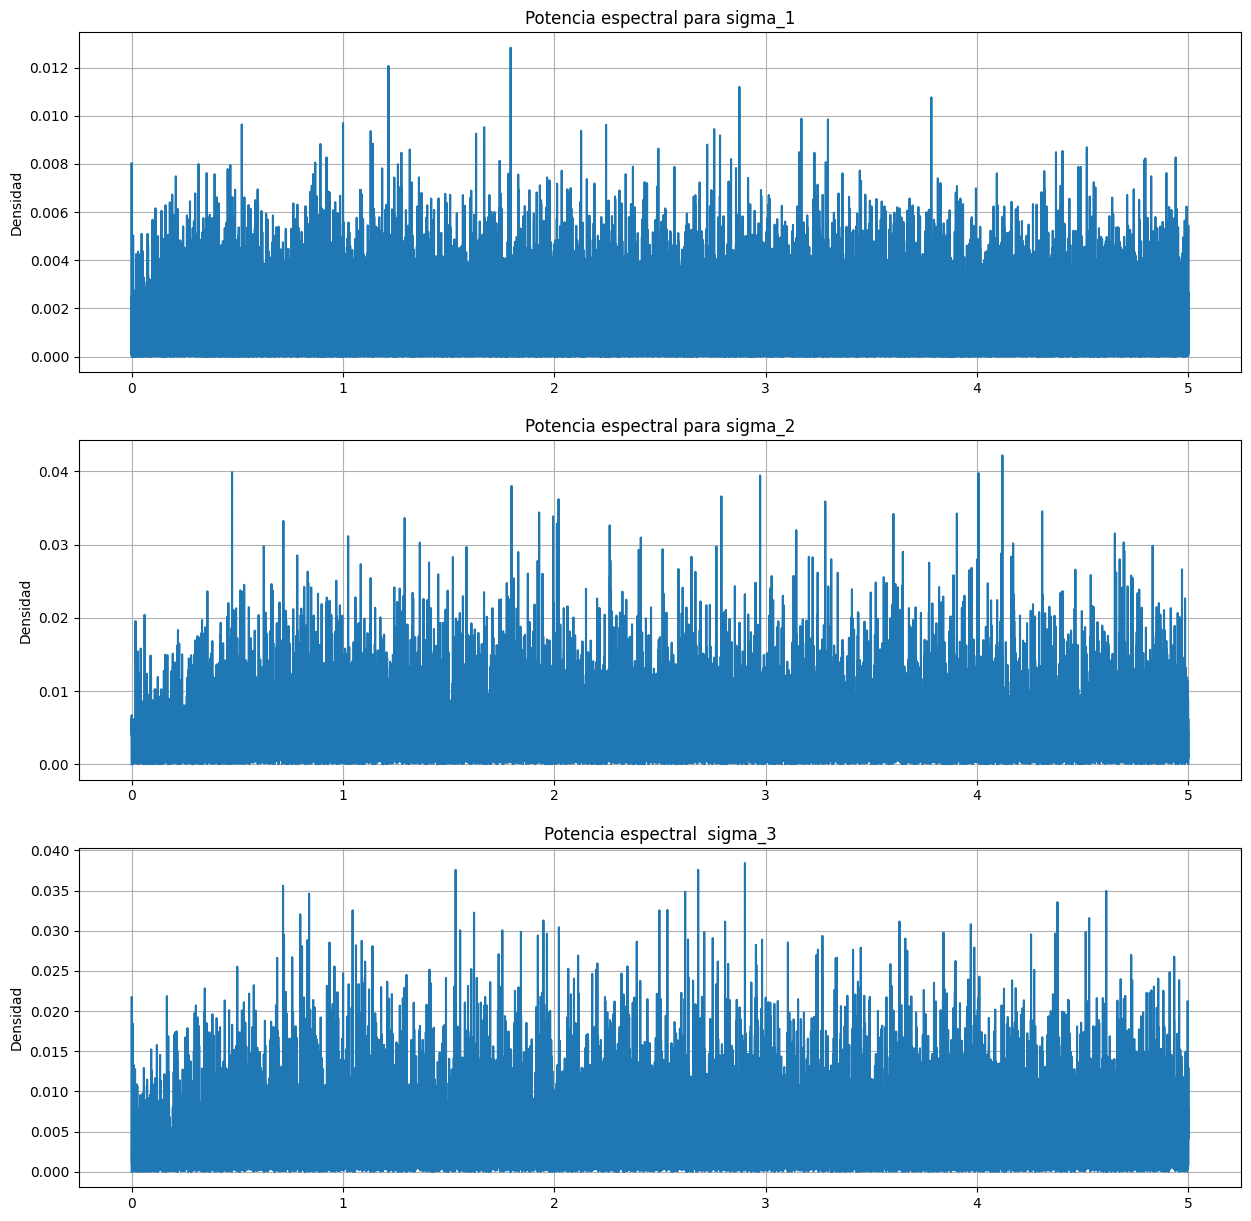

In [ ]:
#graficas espectro de potencia
plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
plt.title('Potencia espectral para sigma_1')
plt.plot(f_1,Pxx_1)
plt.ylabel('Densidad')
plt.grid()

plt.subplot(3,1,2)
plt.title('Potencia espectral para sigma_2')
plt.plot(f_2,Pxx_2)
plt.ylabel('Densidad')
plt.grid()

plt.subplot(3,1,3)
plt.title('Potencia espectral  sigma_3')
plt.plot(f_3,Pxx_3)
plt.ylabel('Densidad')
plt.grid()

plt.show()

## Ejercicio 2.

Con los mismos parámetros anteriores repita el ejercicio 1 pero ahora suponga que el ruido es de color y éste es producido a su vez por un proceso de Ornstein-Ulhenbeck con tiempo de correlación $\tau_s = 20ms$.

1. Muestre la función de autocorrelación y el espectro de la corriente $I_{noise}(t)$ en cada caso
2. Muestre las mismas gráficas del ejercicio 2 y discuta las diferencias

In [ ]:
# TODO
np.random.seed(10)                                               #reproducibilidad

#parametros
R = 1
I_det  = 10
V_rest = -65
V_th = -50
tau_m = 10



#corriente
def corriente_variable(iap ,corriente = 100):
    return corriente

#esta funcion implementa el LIF con ruido blanco gaussiano
def modelosccOU(
              tiempo_inicial=0,
              tiempo_final=200000,
              paso_h=0.1,
              vol_restet = -65,
              cord_inicial = -65,
              corriente = 100,
              v_th1 = -55,
              funcion_corriente = corriente_variable,
              sigma_1= 1,
              tau_s = 20
              ):


    pico_spike = list()
    t = [float(tiempo_inicial)]
    tf = tiempo_final                                          #tiempo final
    h = paso_h                                                 #pasos de tiempo
    n = int(tf/h)                                              #numero de tiempo
    xii = [0]


    V = [float(cord_inicial)]                               #condicion inicial

                                                            # variable del proceso Ornstein-Ulhenbeck inicializada en cero

    for i in range(n):                                      #ciclo principal del metodo de euler
        Vold = V[-1]                                        #variables en t0
        told = t[-1]
        xi =  xii[-1]
        I = funcion_corriente(told, corriente)              #aplicacion de la corriente en el tiempo old

        xi = xi + h * (-xi / tau_s) + (sigma_1 / tau_s) * np.random.normal() * np.sqrt(h)  #actualizacion de es mi noisi

        Vnew  = (Vold + h*((-(Vold - vol_restet) + (R * corriente + xi )) / 10)) + (sigma_1 * np.random.normal() * np.sqrt(h))    #LIF ahora con corriente total incluyendo ruido de color



        if Vnew <= v_th1:                                    #condicion de reinicio de V
            V.append(Vnew)                                   #si vnew es menor que v_th se agrega el new
            tnew =  told + h
            t.append(tnew)
        else:                                               #si no se agrega el reset

                                                            #vi que el V no lleganba hasta el umbral sino que se quedaba hasta  el valor que tenia un paso antes que podia ser muy inferior al umbral
                                                            #lo reformule para que V = Vth en el punto donde sucede y se reinicie un paso luego
            V.append(v_th1)
            pico_spike.append(told)
            t.append(told)
            tnew = told + h


            V.append(vol_restet)

            t.append(tnew)
            xii.append(xi)

    return xii,t,V,pico_spike                                     #variables de interes (retorno)

In [ ]:
tfou = 216000
picospikeou = list()
tiempoou = list()
voltajeou = list()
xii1 = list()
while len(picospikeou)<= 1000:
    xii1,tiempoou,voltajeou,picospikeou = modelosccOU(tiempo_final= tfou,vol_restet =-65,v_th1 = -50, corriente= 10,sigma_1 = 1)
    tfou += 10000


In [ ]:
tfou2 = 50000
picospikeou2 = list()
tiempoou2 = list()
voltajeou2 = list()
xii2 = list()
while len(picospikeou2)<= 1000:
    xii2,tiempoou2,voltajeou2,picospikeou2 = modelosccOU(tiempo_final= tfou2,vol_restet =-65,v_th1 = -50, corriente= 10,sigma_1 = 2)
    tfou2 += 1000


In [ ]:
tfou3 = 5000
picospikeou3 = list()
tiempoou3 = list()
voltajeou3 = list()
xii3 = 3
while len(picospikeou3)<= 1000:
    xii3,tiempoou3,voltajeou3,picospikeou3 = modelosccOU(tiempo_final= tfou3,vol_restet =-65,v_th1 = -50, corriente= 10,sigma_1 = 3)
    tfou3 += 10000

In [ ]:
#para grafica spikes

#sigma_1
V_spikesou = np.full_like(picospikeou, fill_value=-50)  #diferencias entre los tiempo que nos da la distribucion de isi
t_spikeou = np.array(picospikeou)
#sigma_2
V_spikes2ou = np.full_like(picospikeou2, fill_value=-50)
t_spike2ou = np.array(picospikeou2)
#sigma_3
V_spikes3ou = np.full_like(picospikeou3, fill_value=-50)
t_spike3ou = np.array(picospikeou3)

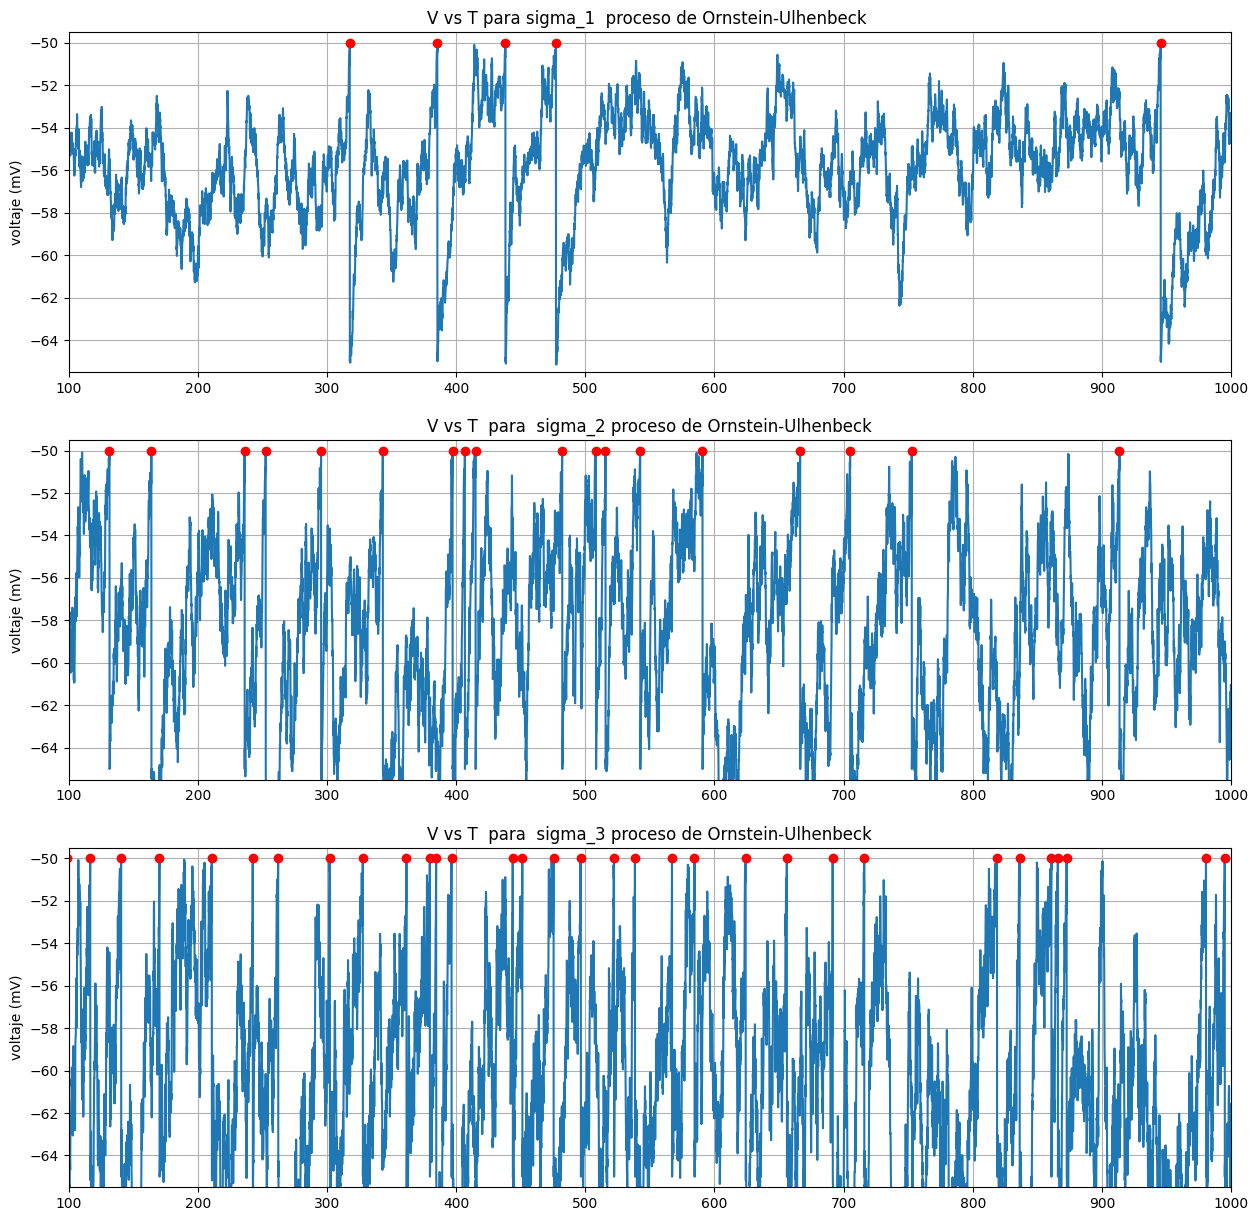

In [ ]:
#grafica de los potenciales de membrana

plt.figure(figsize=(15,15))


plt.subplot(3,1,1)
plt.title('V vs T para sigma_1  proceso de Ornstein-Ulhenbeck ')
plt.plot(tiempoou,voltajeou)
plt.plot(t_spikeou,V_spikesou, 'ro')
plt.xlim(100,1000)
plt.ylim(-65.5,-49.5)

plt.ylabel('voltaje (mV)')
plt.grid()


plt.subplot(3,1,2)
plt.title('V vs T  para  sigma_2 proceso de Ornstein-Ulhenbeck')
plt.plot(tiempoou2,voltajeou2)
plt.plot(t_spike2ou,V_spikes2ou, 'ro')

plt.xlim(100,1000)
plt.ylim(-65.5,-49.5)

plt.ylabel('voltaje (mV)')
plt.grid()

plt.subplot(3,1,3)
plt.title('V vs T  para  sigma_3 proceso de Ornstein-Ulhenbeck')
plt.plot(tiempoou3,voltajeou3)
plt.plot(t_spike3ou,V_spikes3ou, 'ro')
plt.xlim(100,1000)
plt.ylim(-65.5,-49.5)

plt.ylabel('voltaje (mV)')
plt.grid()



plt.show()

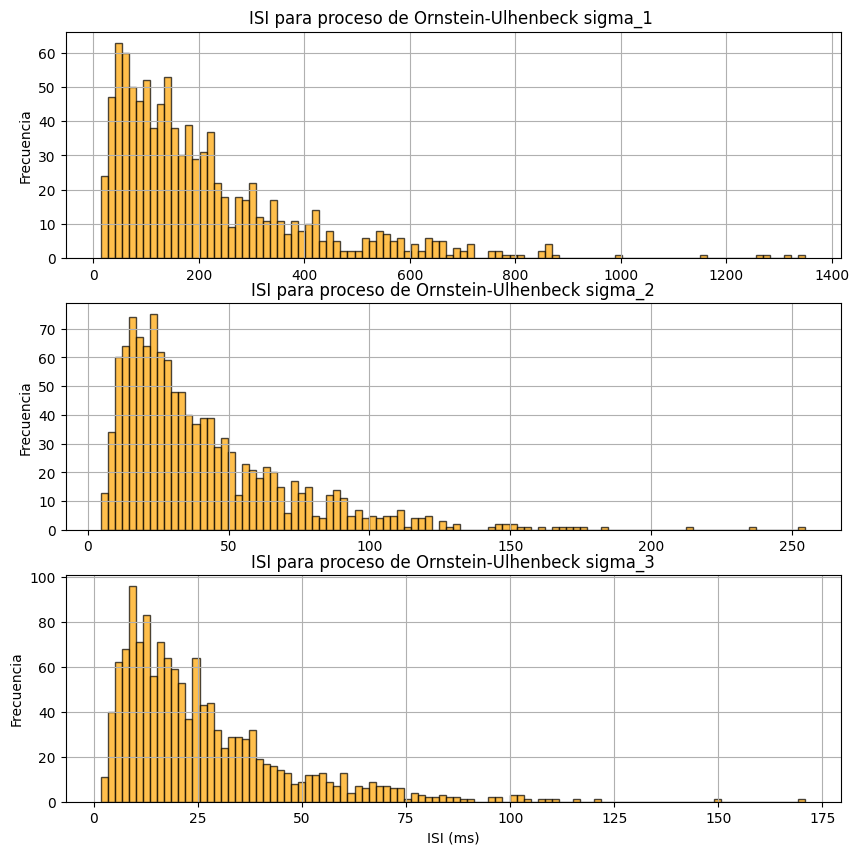

In [ ]:
#isi
isiou = np.diff(picospikeou)
isi2ou = np.diff(picospikeou2)
isi3ou = np.diff(picospikeou3)


plt.figure(figsize = (10,10))
plt.subplot(3,1,1)
plt.title('ISI para proceso de Ornstein-Ulhenbeck sigma_1 ')
plt.hist(isiou, bins=100, color='orange', alpha=0.7,edgecolor='black')

plt.ylabel('Frecuencia')
plt.grid()


plt.subplot(3,1,2)
plt.title('ISI para proceso de Ornstein-Ulhenbeck sigma_2')
plt.hist(isi2ou, bins=100, color='orange', alpha=0.7,edgecolor='black')

plt.ylabel('Frecuencia')
plt.grid()

plt.subplot(3,1,3)
plt.title('ISI para proceso de Ornstein-Ulhenbeck sigma_3')
plt.hist(isi3ou, bins=100, color='orange', alpha=0.7,edgecolor='black')
plt.xlabel('ISI (ms)')
plt.ylabel('Frecuencia')
plt.grid()


plt.show()

In [ ]:
#aqui se aplica la funcion sibre los tiempos de los picos de spikes
spikes_binario_1ou = peaks_01_LIF(picospikeou, tfou,   5)
spikes_binario_2ou = peaks_01_LIF(picospikeou2, tfou2, 5)
spikes_binario_3ou = peaks_01_LIF(picospikeou3, tfou3, 5)

In [ ]:
bins_usoou  = np.arange(0,tfou  ,5)
bins_uso2ou = np.arange(0,tfou2 ,5)
bins_uso3ou = np.arange(0,tfou3 ,5)

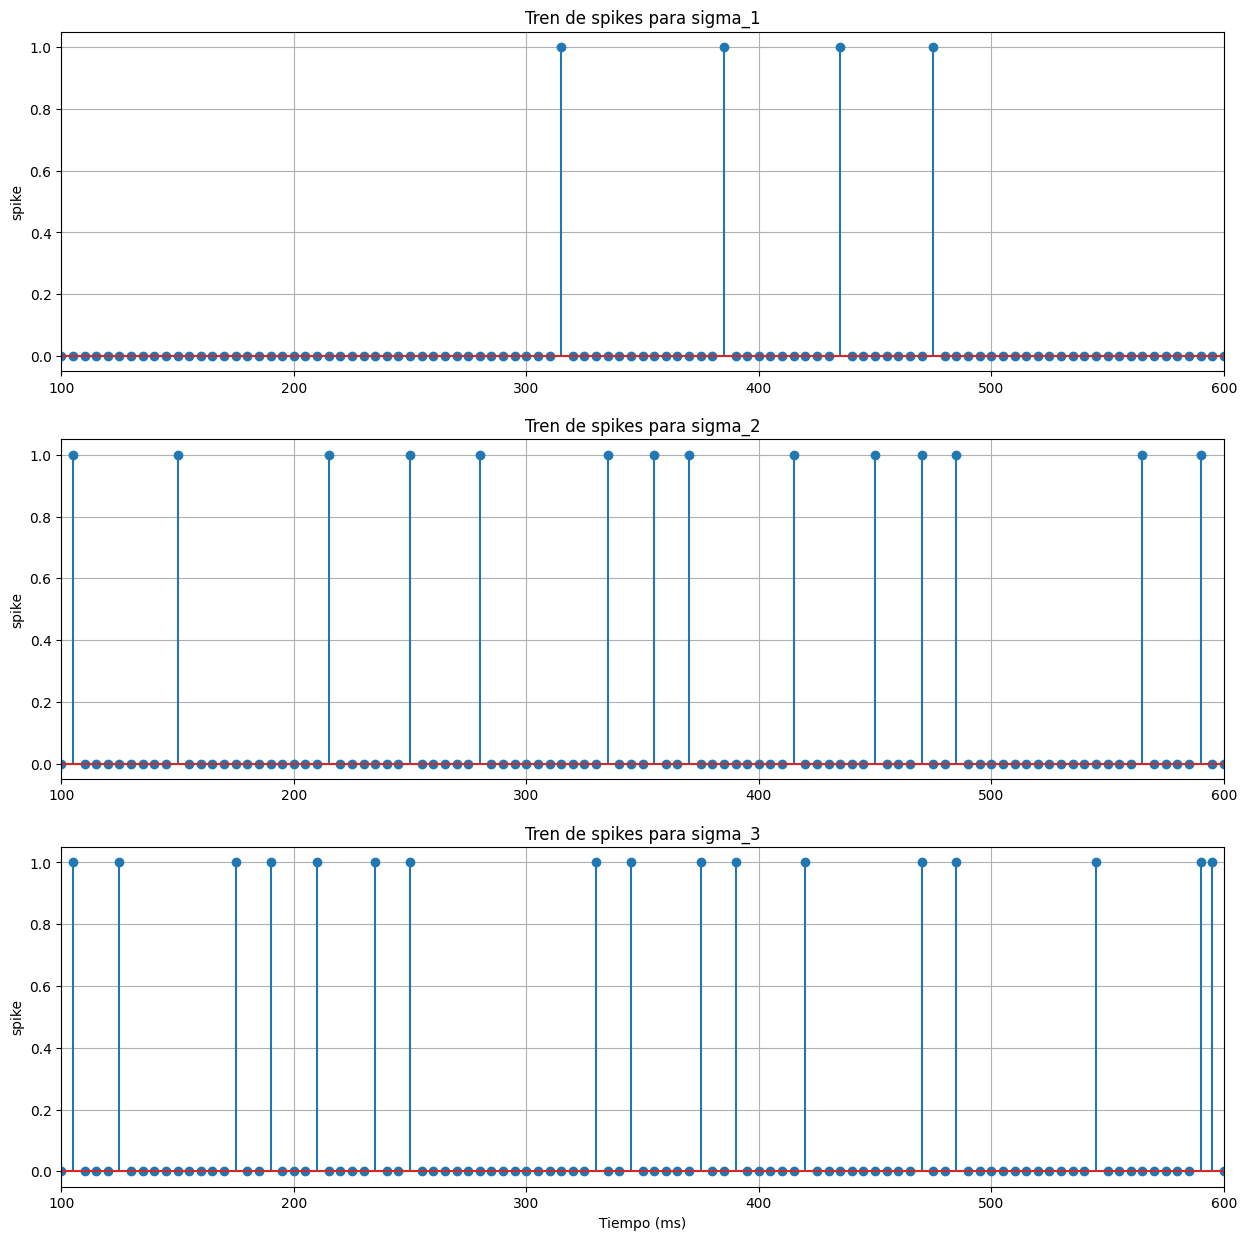

In [ ]:
plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
plt.title('Tren de spikes para sigma_1')
plt.stem(bins_usoou,spikes_binario_1ou)
plt.ylabel('spike')
plt.xlim(100,600)
plt.grid()

plt.subplot(3,1,2)
plt.title('Tren de spikes para sigma_2')
plt.stem(bins_uso2ou,spikes_binario_2ou)
plt.ylabel('spike')
plt.xlim(100,600)
plt.grid()

plt.subplot(3,1,3)
plt.title('Tren de spikes para sigma_3')
plt.stem(bins_uso3ou,spikes_binario_3ou)
plt.ylabel('spike')
plt.xlim(100,600)
plt.xlabel('Tiempo (ms)')
plt.grid()

plt.show()

In [ ]:
correlacion_sigma_1ou = np.correlate(np.array(spikes_binario_1ou) - np.mean(np.array(spikes_binario_1ou)),
                                   np.array(spikes_binario_1ou) - np.mean(np.array(spikes_binario_1ou)),
                                   mode='full') / len(spikes_binario_1ou)

correlacion_sigma_2ou = np.correlate(np.array(spikes_binario_2ou) - np.mean(np.array(spikes_binario_2ou)),
                                   np.array(spikes_binario_2ou) - np.mean(np.array(spikes_binario_2ou)),
                                   mode='full') / len(spikes_binario_2ou)

correlacion_sigma_3ou = np.correlate(np.array(spikes_binario_3ou) - np.mean(np.array(spikes_binario_3ou)),
                                   np.array(spikes_binario_3ou) - np.mean(np.array(spikes_binario_3ou)),
                                   mode='full') / len(spikes_binario_3ou)

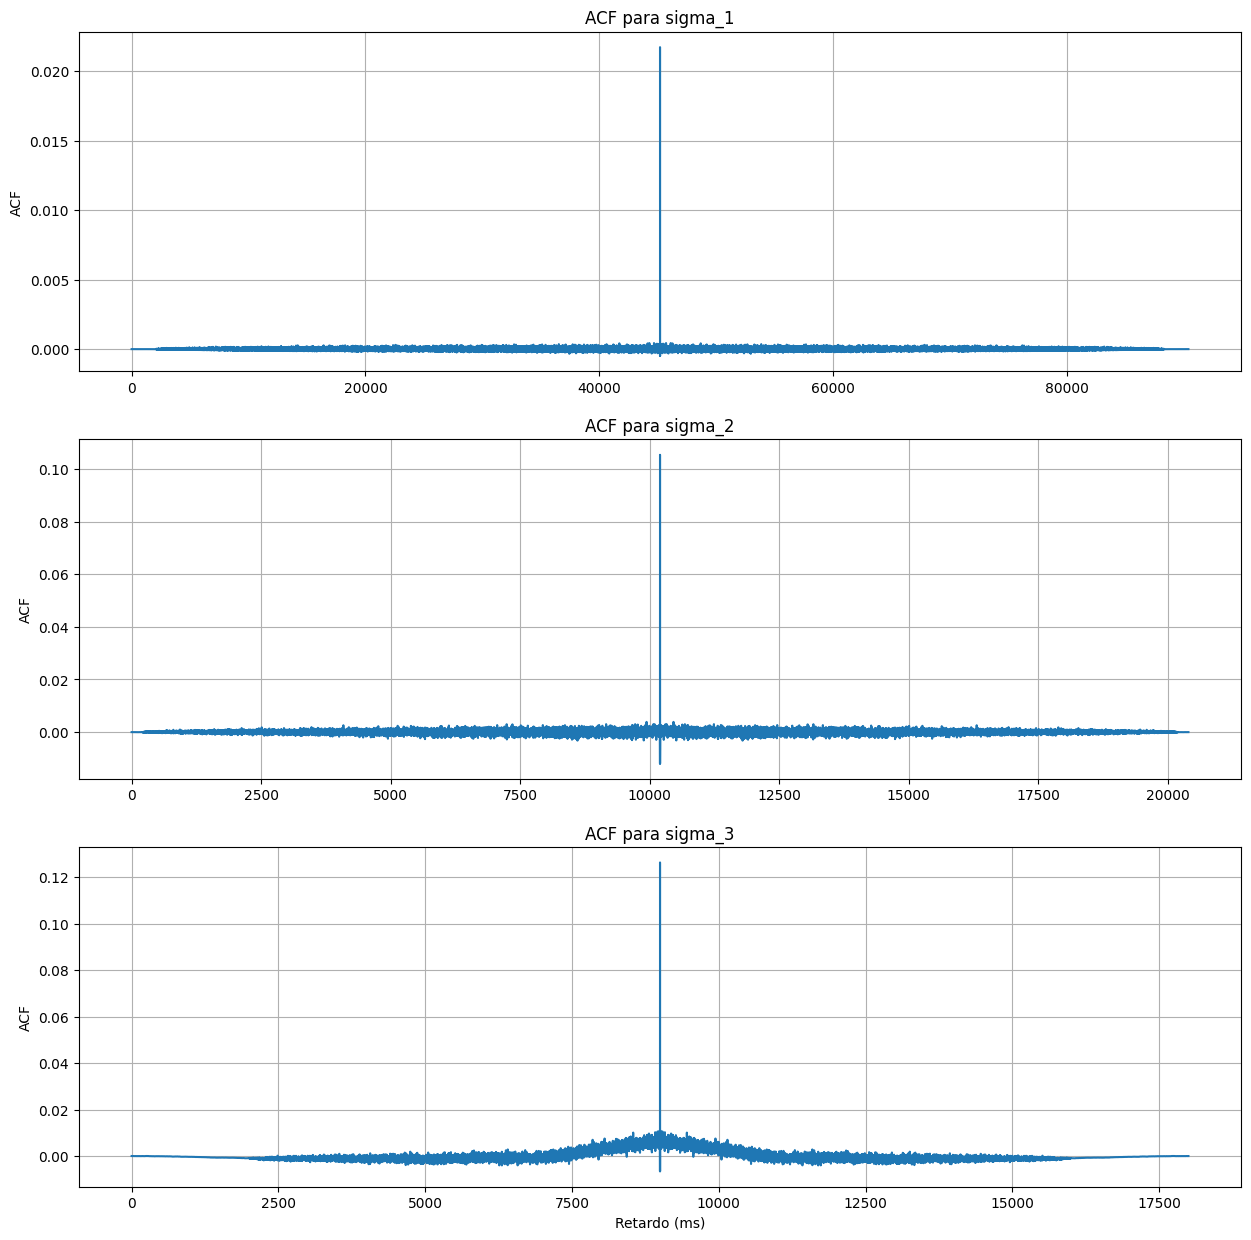

In [ ]:
#graficas coeficiente de correlacion
plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
plt.title('ACF para sigma_1')
plt.plot(correlacion_sigma_1ou)
plt.ylabel('ACF')
plt.grid()

plt.subplot(3,1,2)
plt.title('ACF para sigma_2')
plt.plot(correlacion_sigma_2ou)
plt.ylabel('ACF')
plt.grid()


plt.subplot(3,1,3)
plt.title('ACF para sigma_3')
plt.plot(correlacion_sigma_3ou)
plt.ylabel('ACF')
plt.xlabel('Retardo (ms)')
plt.grid()

plt.show()


In [ ]:
f_1ou , Pxx_1ou= periodogram(spikes_binario_1ou, fs = 2)
f_2ou , Pxx_2ou= periodogram(spikes_binario_2ou, fs = 2)
f_3ou , Pxx_3ou= periodogram(spikes_binario_3ou, fs = 2)

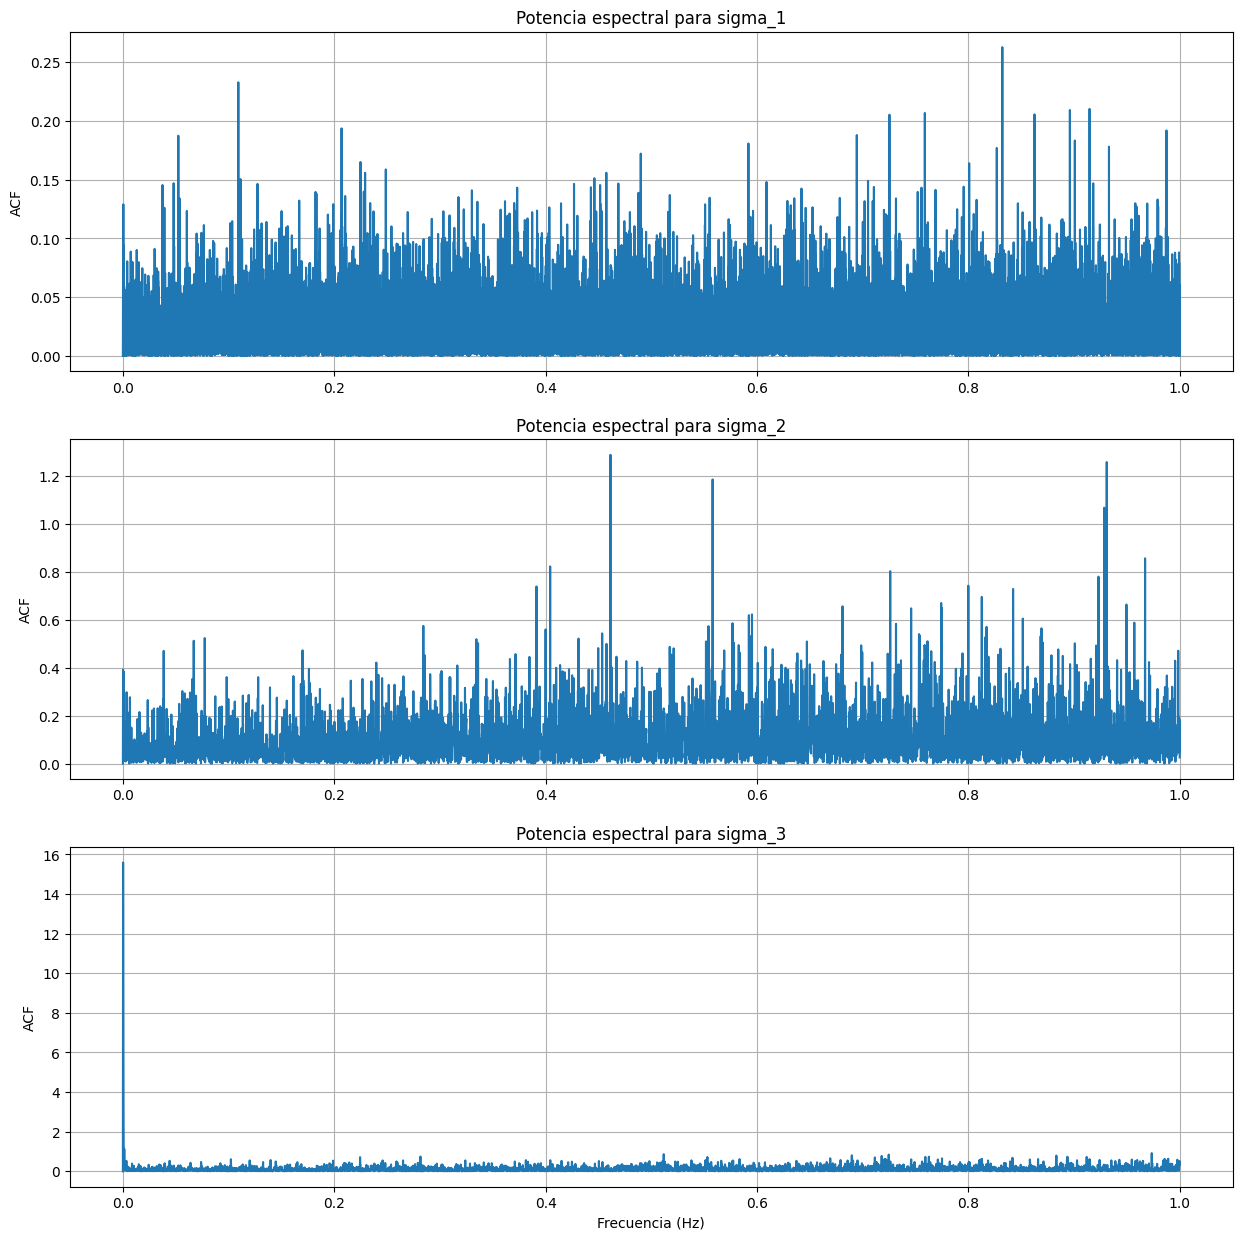

In [ ]:
#graficas potencia espectral

plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
plt.title('Potencia espectral para sigma_1')
plt.plot(f_1ou,Pxx_1ou)
plt.ylabel('ACF')
plt.grid()

plt.subplot(3,1,2)
plt.title('Potencia espectral para sigma_2')
plt.plot(f_2ou,Pxx_2ou)
plt.ylabel('ACF')
plt.grid()

plt.subplot(3,1,3)
plt.title('Potencia espectral para sigma_3')
plt.plot(f_3ou,Pxx_3ou)
plt.ylabel('ACF')
plt.xlabel('Frecuencia (Hz)')
plt.grid()

plt.show()


In [ ]:
#densidad Inoisy

xii = np.array(xii1)

xiicorr = np.correlate(xii - np.mean(xii),
                                   np.array(xii) - np.mean(xii),
                                   mode='full') / len(xii)


frecuencias, Pxx = periodogram(xiicorr, fs = 1/0.1)

xii2 = np.array(xii2)
xiicorr2 = np.correlate(xii2 - np.mean(xii2),
                                   np.array(xii2) - np.mean(xii2),
                                   mode='full') / len(xii2)
frecuencias2, Pxx2 = periodogram(xiicorr2, fs = 1/0.1)



xii3 = np.array(xii3)
xiicorr3 = np.correlate(xii3 - np.mean(xii3),
                                   np.array(xii3) - np.mean(xii3),
                                   mode='full') / len(xii3)
frecuencias3, Pxx3 = periodogram(xiicorr3, fs = 1/0.1)

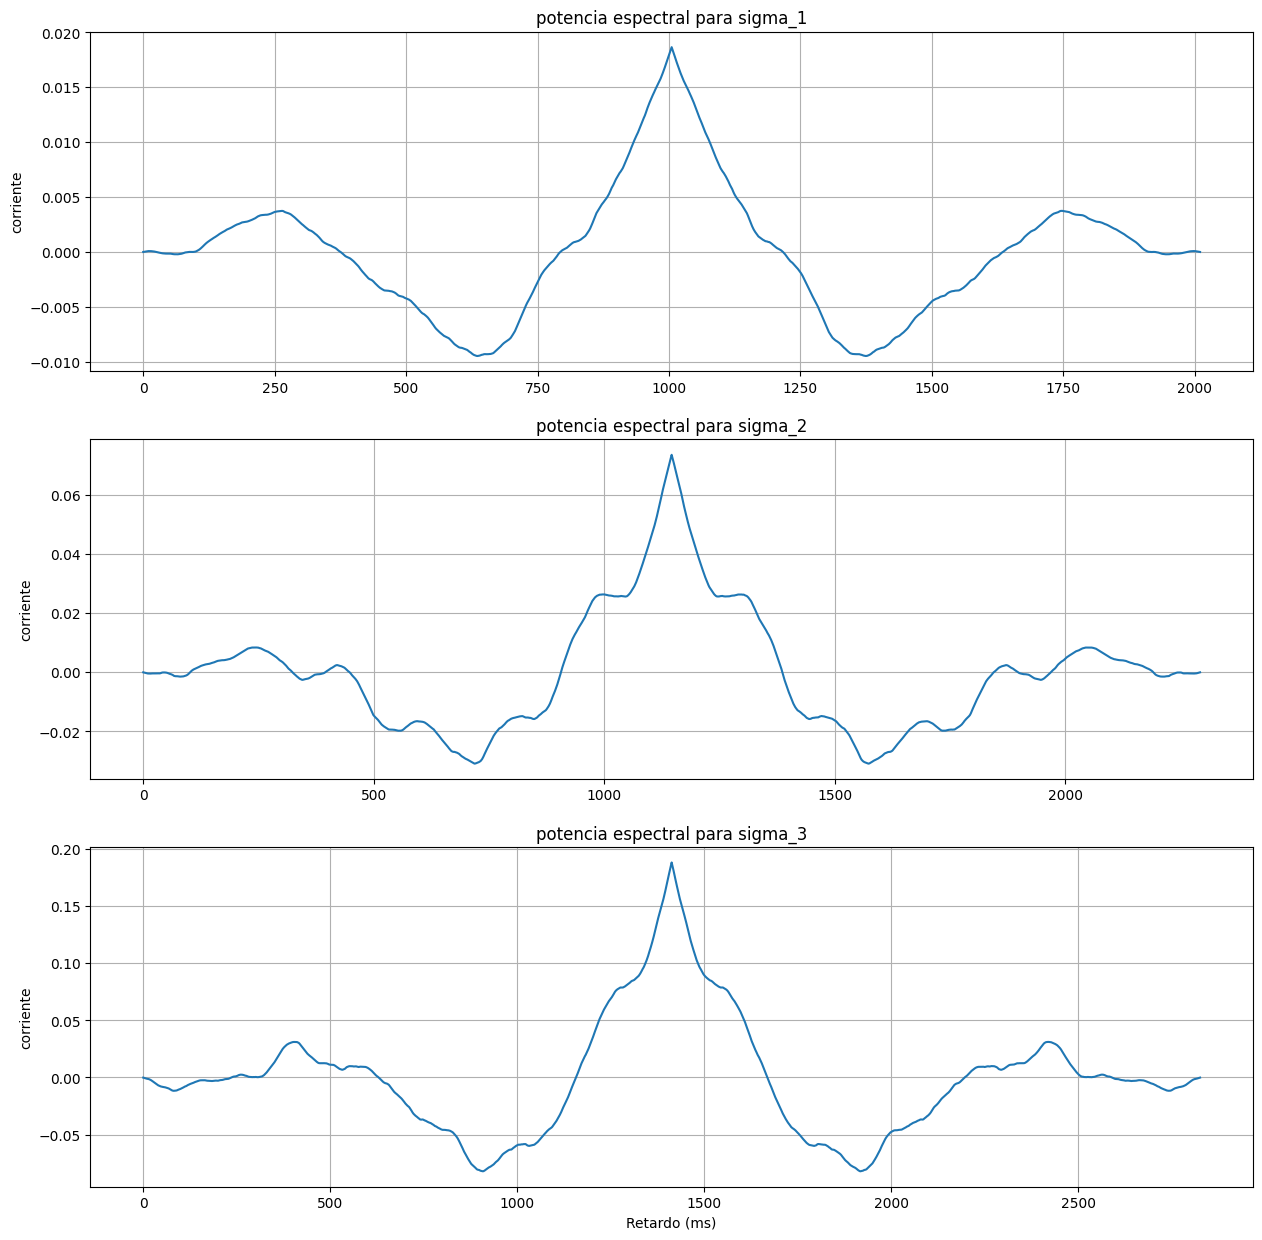

In [ ]:
plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
plt.title('potencia espectral para sigma_1')
plt.plot(xiicorr)
plt.ylabel('corriente')
plt.grid()

plt.subplot(3,1,2)
plt.title('potencia espectral para sigma_2')
plt.plot(xiicorr2)
plt.ylabel('corriente')
plt.grid()

plt.subplot(3,1,3)
plt.title('potencia espectral para sigma_3')
plt.plot(xiicorr3)
plt.ylabel('corriente')
plt.xlabel('Retardo (ms)')
plt.grid()

plt.show()


# CONCLUCIONES:

por inspeccion visual se aprecia que las graficas en el ISI y en las densidades de potencia son muy similares varion en escala , lo cual se puede deber a la relacion con la ditribucion del ruido que en genreal es similar pero con diferencias no tan evidentes en los sesgos de las graficas.

Tal vez las diferencias mas notorias en las graficas y en general en la construccion de los programas son los tiempo en los que los modelos con las variaciones de sigma lograban llegar a los 100 spieks pues para los LIF  con ruido blanco lograban llegar mas rapido a lo 1000 e incluso podemos identificar mas lineas de spikes en las figuras del potencial de menbrana  a diferencia de Ornstein-Ulhenbeck (OE), lo que derivo en muestreos diferentes para los bins de la correlacion y esto lo hice principalmente por dificultades en la convergencia y tiempos de calculo, pues entre menos bins mas agrupacion y menos datos y se reflejo en el grafico del tren binario de spikes  donde se ven algunas pocos unos en la ventena seleccionada.  